In [1]:
import cv2
import os

In [2]:
import os

print(os.listdir("/kaggle/input/datasets/muhammadhaikal0"))

['video-traffic']


In [3]:
video_path = "/kaggle/input/datasets/muhammadhaikal0/video-traffic/istockphoto-981340772-640_adpp_is.mp4"

print(video_path)

/kaggle/input/datasets/muhammadhaikal0/video-traffic/istockphoto-981340772-640_adpp_is.mp4


In [4]:
# buka videonya
# cap adalah object yang kita gunakan untuk membaca video.
cap = cv2.VideoCapture(video_path)

In [5]:
print(cap.isOpened())

True


In [6]:
ret, frame = cap.read()
# ret tuh boolean kl true berhasil baca framme di video

In [7]:
print(ret)
print(frame.shape)

True
(432, 768, 3)


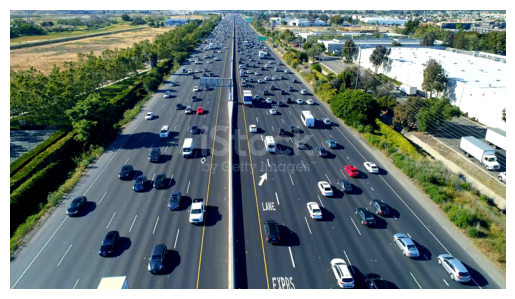

In [8]:
# menampilkan frame
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [9]:
# release ini kaya: kaya sudah selesai menggunakan video ini
cap.release()

In [10]:
# membaca semua frame
cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # sementara kita liat framenya
    cv2.imshow("Video: ", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

# karna di kaggle gabisa, kita pake cara lain dibawah ini

In [ ]:
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Width:", width)
print("Height:", height)
print("Total frames:", frame_count)

cap.release()

In [ ]:
# video output 
output_path = "/kaggle/working/traffic_detect.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [ ]:
cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    results = model.predict(
        source=frame,
        conf=0.5,
        verbose=False
    )

    annotated_frame = results[0].plot()

    out.write(annotated_frame)

cap.release()
out.release()